# CS4603 PA4 — Document Analyst

## Part 0: Document Ingestion and Vector Search

In [0]:
# %cd /Workspace/Users/m.harisbaig7@gmail.com/cs4603-pa4
# %pip install -q -e .
%pip install -q -e /Workspace/Users/m.harisbaig7@gmail.com/cs4603-pa4

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import os

SCOPE = "cs4603-deploy"

os.environ["DATABRICKS_HOST"] = dbutils.secrets.get(
    scope=SCOPE, key="DATABRICKS_HOST"
)
os.environ["DATABRICKS_TOKEN"] = dbutils.secrets.get(
    scope=SCOPE, key="DATABRICKS_TOKEN"
)
os.environ["DATABRICKS_MODEL"] = dbutils.secrets.get(
    scope=SCOPE, key="DATABRICKS_MODEL"
)

os.environ["EMBEDDINGS_ENDPOINT"] = "databricks-gte-large-en"
os.environ["VECTOR_SEARCH_ENDPOINT"] = "haris-vs-endpoint"
os.environ["VECTOR_SEARCH_INDEX"] = (
    "workspace.default.haris_analyst_index"
)
os.environ["SOURCE_TABLE"] = (
    "workspace.default.haris_analyst_chunks"
)

print("Notebook configuration loaded securely")

Notebook configuration loaded securely


In [0]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    "/Workspace/Users/m.harisbaig7@gmail.com/cs4603-pa4"
)

print("Repository exists:", PROJECT_ROOT.exists())
print("Agent directory exists:", (PROJECT_ROOT / "agent").exists())

assert PROJECT_ROOT.exists(), f"Repository not found: {PROJECT_ROOT}"
assert (PROJECT_ROOT / "agent").exists(), "agent/ directory not found"

project_path = str(PROJECT_ROOT)

if project_path not in sys.path:
    sys.path.insert(0, project_path)

os.chdir(PROJECT_ROOT)

import agent
import client

print("Project packages imported successfully")

Repository exists: True
Agent directory exists: True
Project packages imported successfully


In [0]:
%sql
SHOW CATALOGS;

catalog
samples
system
workspace


In [0]:
%sql
SHOW SCHEMAS IN workspace;

databaseName
default
information_schema
rag_data


In [0]:
%sql
CREATE VOLUME IF NOT EXISTS workspace.default.pa4;

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW parsed_docs AS
SELECT
    path AS source,
    ai_parse_document(content) AS parsed
FROM READ_FILES(
    '/Volumes/workspace/default/pa4/annual_report.pdf',
    format => 'binaryFile'
);

In [0]:
%sql
SELECT source, parsed
FROM parsed_docs;

source parsed dbfs:/Volumes/workspace/default/pa4/annual_report.pdf {"document":{"elements":[{"bbox":[{"coord":[195,417,996,489],"page_id":0}],"confidence":0.9998,"content":"Meridian Motor Corporation","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[493,519,699,558],"page_id":0}],"confidence":0.9997,"content":"Annual Report","description":null,"id":1,"type":"text"},{"bbox":[{"coord":[251,556,941,600],"page_id":0}],"confidence":1,"content":"For the fiscal year ended March 31, 2023 (FY2023)","description":null,"id":2,"type":"text"},{"bbox":[{"coord":[249,654,944,697],"page_id":0}],"confidence":0.9919,"content":"Tokyo Stock Exchange (Prime Market) · Code 7000","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[109,1601,501,1629],"page_id":0}],"confidence":0.9991,"content":"Meridian Motor Corporation — Annual Report FY2023","description":null,"id":4,"type":"page_footer"},{"bbox":[{"coord":[1022,1601,1081,1629],"page_id":0}],"confidence":0.9996,"content":"Page 1","description":null,"id":5,"type":"page_number"},{"bbox":[{"coord":[122,128,415,164],"page_id":1}],"confidence":0.9998,"content":"Table of Contents","description":null,"id":6,"type":"title"},{"bbox":[{"coord":[121,194,650,663],"page_id":1}],"confidence":0.9959,"content":" Letter from the President and CEO 3 Financial Highlights — Five-Year Summary 4 Consolidated Statement of Operations 5 About Meridian Motor Corporation 6 Segment Information 7 Regional Performance 8 Consolidated Balance Sheet 9 Consolidated Statements of Cash Flows 10 Research & Development and Capital Investment 11 Risk Factors 12 Outlook and Guidance (FY2024) 13 Notes and Glossary 14 ","description":null,"id":7,"type":"table"},{"bbox":[{"coord":[121,709,872,735],"page_id":1}],"confidence":0.9989,"content":"All figures in this report are fictional and provided solely for CS4603 coursework.","description":null,"id":8,"type":"text"},{"bbox":[{"coord":[112,1605,497,1628],"page_id":1}],"confidence":0.9988,"content":"Meridian Motor Corporation — Annual Report FY2023","description":null,"id":9,"type":"page_footer"},{"bbox":[{"coord":[1024,1605,1078,1628],"page_id":1}],"confidence":0.9995,"content":"Page 2","description":null,"id":10,"type":"page_number"},{"bbox":[{"coord":[122,128,686,165],"page_id":2}],"confidence":0.9999,"content":"Letter from the President and CEO","description":null,"id":11,"type":"section_header"},{"bbox":[{"coord":[121,194,1070,312],"page_id":2}],"confidence":0.9952,"content":"To our shareholders, customers, and employees: Meridian Motor Corporation delivered record results in the fiscal year ended March 31, 2023. Consolidated net revenue rose 16.2% to ¥16,910 billion (¥16.91 trillion), and operating profit increased 24.2% to ¥1,124 billion. Net income attributable to owners of the parent reached ¥1,107 billion, our highest ever.","description":null,"id":12,"type":"text"},{"bbox":[{"coord":[121,331,1070,451],"page_id":2}],"confidence":0.9966,"content":"Demand recovered strongly across all major markets as supply-chain constraints eased. Global vehicle unit sales grew to 4.07 million units, up from 3.68 million a year earlier, led by our electrified line-up in North America and Asia. Our Motorcycle business remained the profitability anchor of the group, with a 14.3% operating margin.","description":null,"id":13,"type":"text"},{"bbox":[{"coord":[121,470,1070,558],"page_id":2}],"confidence":0.9859,"content":"We continued to invest for the long term. Research and development expense rose to ¥880 billion, or 5.2% of net revenue, concentrated on battery-electric platforms, software-defined vehicle architecture, and advanced driver assistance. Capital expenditure was ¥590 billion.","description":null,"id":14,"type":"text"},{"bbox":[{"coord":[121,577,1070,667],"page_id":2}],"confidence":0.9796,"content":"Looking ahead to FY2024, we forecast net revenue of ¥18.20 trillion and operating profit of ¥1.30 trillion, and we have raised the annual dividend to ¥150 per share. On beha

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW prepared_docs AS
SELECT
    source,
    ai_prep_search(parsed) AS prepared
FROM parsed_docs;

In [0]:
%sql
SELECT source, prepared
FROM prepared_docs;

source prepared dbfs:/Volumes/workspace/default/pa4/annual_report.pdf {"document":{"contents":[{"chunk_id":"caf4fcb35bc64b0bb284602ab0cf1a5a_0","chunk_position":0,"chunk_to_embed":"Company: Meridian Motor Corporation\nDocument Type: Annual Report\nFiscal Year: FY2023\nStock Exchange: Tokyo Stock Exchange (Prime Market)\nTicker Code: 7000\nDocument Title: Table of Contents\nTables: Tokyo Stock Exchange (Prime Market) · Code 7000\nContains: table, text\n\nMeridian Motor Corporation's FY2023 Annual Report covering the fiscal year ended March 31 2023.\n\nTable summary: The table lists FY2023 Annual Report sections, covering the fiscal year ended March 31 2023 and a five‑year summary.\n\nContent:\n\nAnnual Report\n\nFor the fiscal year ended March 31, 2023 (FY2023)\n\nTokyo Stock Exchange (Prime Market) · Code 7000\n\n Letter from the President and CEO 3 Financial Highlights — Five-Year Summary 4 Consolidated Statement of Operations 5 About Meridian Motor Corporation 6 Segment Information 7 Regional Performance 8 Consolidated Balance Sheet 9 Consolidated Statements of Cash Flows 10 Research & Development and Capital Investment 11 Risk Factors 12 Outlook and Guidance (FY2024) 13 Notes and Glossary 14 \n\n\nRelated questions:\nWhat are the financial highlights for the past five years? \nWhere can I find the consolidated statement of operations? \nWhich section contains the regional performance information? \nHow can I view the research & development and capital investment details? \nWhere is the outlook and guidance for FY2024 located?","chunk_to_retrieve":"\nAnnual Report\n\nFor the fiscal year ended March 31, 2023 (FY2023)\n\nTokyo Stock Exchange (Prime Market) · Code 7000\n\n Letter from the President and CEO 3 Financial Highlights — Five-Year Summary 4 Consolidated Statement of Operations 5 About Meridian Motor Corporation 6 Segment Information 7 Regional Performance 8 Consolidated Balance Sheet 9 Consolidated Statements of Cash Flows 10 Research & Development and Capital Investment 11 Risk Factors 12 Outlook and Guidance (FY2024) 13 Notes and Glossary 14 \n","pages":[{"image_uri":"","page_id":0},{"image_uri":"","page_id":1}]},{"chunk_id":"caf4fcb35bc64b0bb284602ab0cf1a5a_1","chunk_position":1,"chunk_to_embed":"Company: Meridian Motor Corporation\nDocument Type: Annual Report\nFiscal Year: FY2023\nStock Exchange: Tokyo Stock Exchange (Prime Market)\nTicker Code: 7000\nDocument Title: Financial Highlights — Five-Year Summary\nSection: Letter from the President and CEO\nTables: over the past five fiscal years. In FY2023, net revenue was ¥16.91 trillion and net income attrib... (¥ billions (except per-share), FY2019, FY2020, FY2021, FY2022, ...)\nContains: table, text\n\nMeridian Motor Corporation's FY2023 Annual Report covering the fiscal year ended March 31 2023.\n\nTable summary: Financial and operational metrics for Meridian Motor Corp from FY2019 through FY2023.\n\nContent:\n\nAll figures in this report are fictional and provided solely for CS4603 coursework.\n\nTo our shareholders, customers, and employees: Meridian Motor Corporation delivered record results in the fiscal year ended March 31, 2023. Consolidated net revenue rose 16.2% to ¥16,910 billion (¥16.91 trillion), and operating profit increased 24.2% to ¥1,124 billion. Net income attributable to owners of the parent reached ¥1,107 billion, our highest ever.\n\nDemand recovered strongly across all major markets as supply-chain constraints eased. Global vehicle unit sales grew to 4.07 million units, up from 3.68 million a year earlier, led by our electrified line-up in North America and Asia. Our Motorcycle business remained the profitability anchor of the group, with a 14.3% operating margin.\n\nWe continued to invest for the long term. Research and development expense rose to ¥880 billion, or 5.2% of net revenue, concentrated on battery-electric platforms, software-defined vehicle architecture, and advanced driver assistance. Capital expenditure was ¥590 billion.\n\nLoo

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.default.haris_analyst_chunks
TBLPROPERTIES (delta.enableChangeDataFeed = true)
AS
SELECT
    chunk.value:chunk_id::STRING AS chunk_id,
    chunk.value:chunk_to_retrieve::STRING AS chunk_to_retrieve,
    chunk.value:chunk_to_embed::STRING AS chunk_to_embed,
    element_at(split(d.source, '/'), -1) AS source,
    chunk.value:pages[0].page_id::INT + 1 AS page
FROM prepared_docs AS d,
LATERAL variant_explode(d.prepared:document.contents) AS chunk
WHERE chunk.value:chunk_id IS NOT NULL;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT
    chunk_id,
    source,
    page,
    length(chunk_to_retrieve) AS text_length
FROM workspace.default.haris_analyst_chunks
ORDER BY page;

chunk_id,source,page,text_length
1ba9f5e44c1d4f2ab05ed840b991621c_0,annual_report.pdf,1,820
1ba9f5e44c1d4f2ab05ed840b991621c_1,annual_report.pdf,2,2890
1ba9f5e44c1d4f2ab05ed840b991621c_2,annual_report.pdf,4,1607
1ba9f5e44c1d4f2ab05ed840b991621c_3,annual_report.pdf,5,1688
1ba9f5e44c1d4f2ab05ed840b991621c_4,annual_report.pdf,7,968
1ba9f5e44c1d4f2ab05ed840b991621c_5,annual_report.pdf,8,3756
1ba9f5e44c1d4f2ab05ed840b991621c_6,annual_report.pdf,13,1682


In [0]:
%sql
SELECT
    COUNT(*) AS total_chunks,
    COUNT(DISTINCT chunk_id) AS unique_chunks
FROM workspace.default.haris_analyst_chunks;

total_chunks,unique_chunks
7,7


### Part 0.1: Vector Search Endpoint

In [0]:
from databricks.vector_search.client import VectorSearchClient

VS_ENDPOINT = "haris-vs-endpoint"

client = VectorSearchClient()

try:
    endpoint = client.get_endpoint(VS_ENDPOINT)
    print(f"Endpoint already exists: {VS_ENDPOINT}")
except Exception:
    client.create_endpoint(
        name=VS_ENDPOINT,
        endpoint_type="STANDARD",
    )
    print(f"Endpoint creation started: {VS_ENDPOINT}")

/home/spark-b7f11374-b0fd-4743-9c87-d5/.ipykernel/309/command-8657758301353015-1117840176:1: DeprecationWarning: databricks-vectorsearch is deprecated and has been renamed to databricks-ai-search. Imports under 'databricks.vector_search.*' will continue to work as a thin re-export of 'databricks.ai_search.*', but new code should switch to 'pip install databricks-ai-search' and 'from databricks.ai_search.* import ...'.
  from databricks.vector_search.client import VectorSearchClient


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Endpoint already exists: haris-vs-endpoint


### Part 0.2: Delta Sync Index

In [0]:
SOURCE_TABLE = "workspace.default.haris_analyst_chunks"
INDEX_NAME = "workspace.default.haris_analyst_index"

try:
    index = client.get_index(
        endpoint_name=VS_ENDPOINT,
        index_name=INDEX_NAME,
    )
    print(f"Index already exists: {INDEX_NAME}")
except Exception:
    index = client.create_delta_sync_index(
        endpoint_name=VS_ENDPOINT,
        source_table_name=SOURCE_TABLE,
        index_name=INDEX_NAME,
        pipeline_type="TRIGGERED",
        primary_key="chunk_id",
        embedding_source_column="chunk_to_retrieve",
        embedding_model_endpoint_name="databricks-gte-large-en",
    )
    print(f"Index creation started: {INDEX_NAME}")

Index already exists: workspace.default.haris_analyst_index


In [0]:
index = client.get_index(
    endpoint_name=VS_ENDPOINT,
    index_name=INDEX_NAME,
)
print(index.describe())

{'name': 'workspace.default.haris_analyst_index', 'endpoint_name': 'haris-vs-endpoint', 'primary_key': 'chunk_id', 'index_type': 'DELTA_SYNC', 'delta_sync_index_spec': {'source_table': 'workspace.default.haris_analyst_chunks', 'embedding_source_columns': [{'name': 'chunk_to_retrieve', 'embedding_model_endpoint_name': 'databricks-gte-large-en'}], 'pipeline_type': 'TRIGGERED', 'pipeline_id': '3316e9b8-60bd-4b02-ab6f-086e6a608dfa'}, 'status': {'detailed_state': 'ONLINE_NO_PENDING_UPDATE', 'message': 'Index creation succeeded. Check latest status: [REDACTED]/explore/data/workspace/default/haris_analyst_index', 'indexed_row_count': 7, 'triggered_update_status': {'last_processed_commit_version': 0, 'last_processed_commit_timestamp': '2026-07-13T22:18:58Z'}, 'ready': True, 'index_url': 'dbc-358be7a6-cc24.cloud.databricks.com/api/2.0/vector-search/indexes/workspace.default.haris_analyst_index'}, 'creator': 'm.harisbaig7@gmail.com', 'endpoint_type': 'STANDARD', 'id': 'd5094553-06d7-40d2-8065-d6

In [0]:
import time

for attempt in range(45):  # maximum 15 minutes
    status = client.get_index(
        endpoint_name=VS_ENDPOINT,
        index_name=INDEX_NAME,
    ).describe()["status"]

    print(f"Attempt {attempt + 1}: {status['detailed_state']}")

    if status.get("ready"):
        print("Index is READY")
        break

    time.sleep(20)
else:
    raise TimeoutError("Index did not become ready within 15 minutes")

Attempt 1: ONLINE_NO_PENDING_UPDATE
Index is READY


In [0]:
index = client.get_index(
    endpoint_name=VS_ENDPOINT,
    index_name=INDEX_NAME,
)

results = index.similarity_search(
    query_text="What was Meridian's net revenue in FY2023?",
    columns=["chunk_id", "chunk_to_retrieve", "source", "page"],
    num_results=3,
)

results

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'manifest': {'column_count': 5,
  'columns': [{'name': 'chunk_id'},
   {'name': 'chunk_to_retrieve'},
   {'name': 'source'},
   {'name': 'page'},
   {'name': 'score'}]},
 'result': {'row_count': 3,
  'data_array': [['22c79f0020ca4824944105a8941c05f3_3',
    '\nGross profit improved to ¥3,350 billion as pricing and mix more than offset higher input costs. The effective tax rate fell to 17.0% following the recognition of previously unrecognized deferred tax assets.\n\nMeridian Motor Corporation is a global mobility company headquartered in Tokyo, Japan, and listed\non the Tokyo Stock Exchange (Prime Market, code 7000). Founded in 1959, the company designs,\nmanufactures, and sells automobiles, motorcycles, and power products, and provides related\nfinancial services.\n\nThe company operates 38 production facilities across 14 countries and employs approximately 210,000 people worldwide. Its four reportable segments are Automobile, Motorcycle, Financial Services, and Power Products & Othe

## Part 1: LangGraph Multi-Agent Application

In [0]:
from config import get_chat_llm
from agent.graph import build_graph

print("PA4 source imports successful")

PA4 source imports successful


In [0]:
llm = get_chat_llm()
response = llm.invoke(
    "Reply with exactly: LLM connection successful"
)
print(response.content)

LLM connection successful


### Part 1.1: Compiled Agent Graph

In [0]:
import langgraph
import langchain
import mcp

print("LangGraph dependencies installed successfully")

LangGraph dependencies installed successfully


Graph compiled successfully


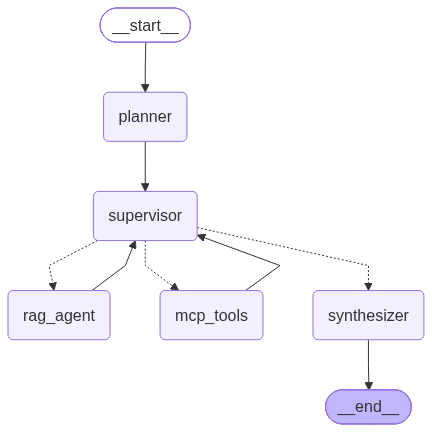

In [0]:
from IPython.display import Image, display
from agent.graph import build_graph

graph = build_graph()
print("Graph compiled successfully")

display(Image(graph.get_graph().draw_mermaid_png()))

### Part 1.2: Retrieval-Only Test

In [0]:
retrieval_result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What was Meridian's net income in FY2023?",
            }
        ]
    },
    config={"recursion_limit": 30},
)

print("Plan:")
for step in retrieval_result["plan"]:
    print("-", step)

print("\nStep results:")
for result in retrieval_result["step_results"]:
    print("-", result)

print("\nFinal answer:")
print(retrieval_result["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Plan:
- Retrieve Meridian's FY2023 net income from the annual report

Step results:
- ¥1,107 billion [source: annual_report.pdf, p.2]

Final answer:
Meridian's net income in FY2023 was ¥1,107 billion, as stated in their annual report [annual_report.pdf, p.2].

Sources: [source: annual_report.pdf, p.2]


### Part 1.3: Computation-Only Test

In [0]:
computation_result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 15% of 2.4 billion?",
            }
        ]
    },
    config={"recursion_limit": 30},
)

print("Plan:")
for step in computation_result["plan"]:
    print("-", step)

print("\nStep results:")
for result in computation_result["step_results"]:
    print("-", result)

print("\nFinal answer:")
print(computation_result["messages"][-1].content)

Plan:
- Convert 2.4 billion into base units
- Calculate 15% of the converted value

Step results:
- 2.4 billion = 2.4e+09 ones
- 2.4e+09 * 0.15 = 3.6e+08

Final answer:
To find 15% of 2.4 billion, we first convert 2.4 billion to 2.4e+09. Then, we multiply this value by 0.15 (which represents 15%). The calculation is as follows:

2.4 billion = 2.4e+09
15% of 2.4 billion = 2.4e+09 * 0.15 = 3.6e+08

Therefore, 15% of 2.4 billion is 3.6e+08, or 360 million.


### Part 1.4: Combined Query and Execution Trace

In [0]:
combined_query = (
    "What was Meridian's net revenue in FY2023, and what would it be "
    "after 3 years of 8% compound annual growth?"
)

combined_events = []

for event in graph.stream(
    {"messages": [{"role": "user", "content": combined_query}]},
    config={"recursion_limit": 30},
    stream_mode="updates",
):
    combined_events.append(event)

    node_name = next(iter(event))
    update = event[node_name]

    print(f"\n--- {node_name.upper()} ---")

    if "plan" in update:
        print("Plan:", update["plan"])
    if "next_agent" in update:
        print("Route:", update["next_agent"])
    if "step_results" in update:
        print("Results:", update["step_results"])
    if "final_answer" in update:
        print("Final answer:", update["final_answer"])


--- PLANNER ---
Plan: ["Retrieve Meridian's FY2023 net revenue from the annual report", 'Calculate the retrieved net revenue after 3 years at 8% compound annual growth']
Results: []

--- SUPERVISOR ---
Route: rag_agent
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.

--- RAG_AGENT ---
Results: ['¥16,910 billion [source: annual_report.pdf, p.2]']

--- SUPERVISOR ---
Route: mcp_tools

--- MCP_TOOLS ---
Results: ['¥16,910 billion [source: annual_report.pdf, p.2]', '16910 at 8% CAGR for 3 years = 21301.7']

--- SUPERVISOR ---
Route: synthesizer

--- SYNTHESIZER ---
Final answer: Meridian's net revenue in FY2023 was ¥16,910 billion. After 3 years of 8% compound annual growth, the net revenue would be approximately ¥21,301.7 billion.

Sources: [source: annual_report.pdf, p.2]


## Part 2: Deployed Model

### Task 2.4: Live Endpoint Verification

In [0]:
import json
import os
import subprocess
import time

HOST = os.environ["DATABRICKS_HOST"].rstrip("/")
TOKEN = os.environ["DATABRICKS_TOKEN"]
ENDPOINT = "haris-document-analyst"

curl_payload = {
    "messages": [
        {
            "role": "user",
            "content": "What was Meridian's net income in FY2023?",
        }
    ]
}

curl_start = time.perf_counter()

curl_result = subprocess.run(
    [
        "curl",
        "-sS",
        "-X",
        "POST",
        f"{HOST}/serving-endpoints/{ENDPOINT}/invocations",
        "-H",
        f"Authorization: Bearer {TOKEN}",
        "-H",
        "Content-Type: application/json",
        "-d",
        json.dumps(curl_payload),
    ],
    capture_output=True,
    text=True,
    check=False,
)

curl_latency = time.perf_counter() - curl_start

print("HTTP client exit code:", curl_result.returncode)
print(f"First request latency: {curl_latency:.2f} seconds")
print("Raw response:")
print(curl_result.stdout or curl_result.stderr)

HTTP client exit code: 0
First request latency: 38.90 seconds
Raw response:
[{"messages": [{"content": "What was Meridian's net income in FY2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "91ebefe3-4042-4b53-860b-cc999c0c7922"}, {"content": "Meridian's net income in FY2023 was \u00a51,107 billion, as stated in their annual report [annual_report.pdf, p.2].\n\nSources: [source: annual_report.pdf, p.2]", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "2ba21cd8-c3d2-4096-9dec-67164351569b", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Retrieve Meridian's FY2023 net income from the annual report"], "current_step_index": 1, "step_results": ["\u00a51,107 billion [source: annual_report.pdf, p.2]"], "next_agent": "synthesizer", "final_answer": "Meridian's net income in FY2023 was \u00a51,107 billion, as stated in their annual report [annual_report.pdf, p.2].\n\nSources: [source

In [0]:
from openai import OpenAI

deployed_client = OpenAI(
    api_key=TOKEN,
    base_url=f"{HOST}/serving-endpoints",
    timeout=300.0,
)

def extract_answer(response) -> str:
    """Extract the final answer from supported endpoint response shapes."""

    if hasattr(response, "choices"):
        return str(response.choices[0].message.content)

    if isinstance(response, list) and response:
        result = response[0]

        final_answer = getattr(result, "final_answer", None)
        if final_answer:
            return str(final_answer)

        if isinstance(result, dict):
            final_answer = result.get("final_answer")
            if final_answer:
                return str(final_answer)
            messages = result.get("messages", [])
        else:
            messages = getattr(result, "messages", [])

        if messages:
            last_message = messages[-1]

            if isinstance(last_message, dict):
                return str(last_message.get("content", ""))

            content = getattr(last_message, "content", None)
            if content:
                return str(content)

    raise ValueError(
        f"Unsupported response: {type(response)} / "
        f"{type(response[0]) if isinstance(response, list) and response else None}"
    )


deployed_queries = {
    "retrieval_only": (
        "What was Meridian's net income in FY2023?"
    ),
    "computation_only": (
        "What is 15% of 2.4 billion?"
    ),
    "combined": (
        "What was Meridian's net revenue in FY2023, and what would it be "
        "after 3 years of 8% compound annual growth?"
    ),
}

deployed_results = {}
deployed_latencies = {}

for name, question in deployed_queries.items():
    started = time.perf_counter()

    response = deployed_client.chat.completions.create(
        model=ENDPOINT,
        messages=[{"role": "user", "content": question}],
    )

    elapsed = time.perf_counter() - started
    answer = extract_answer(response)

    deployed_results[name] = answer
    deployed_latencies[name] = elapsed

    print(f"\n--- {name.upper()} ---")
    print(f"Latency: {elapsed:.2f} seconds")
    print(answer)


--- RETRIEVAL_ONLY ---
Latency: 11.26 seconds
Meridian's net income in FY2023 was ¥1,107 billion, as stated in their annual report [annual_report.pdf, p.2].

Sources: [source: annual_report.pdf, p.2]

--- COMPUTATION_ONLY ---
Latency: 6.30 seconds
To find 15% of 2.4 billion, we first convert 2.4 billion to 2.4e+09. Then, we multiply this value by 0.15 (which represents 15%). The calculation is as follows:

2.4 billion = 2.4e+09
15% of 2.4 billion = 2.4e+09 * 0.15 = 3.6e+08

Therefore, 15% of 2.4 billion is 3.6e+08, or 360 million.

--- COMBINED ---
Latency: 6.17 seconds
Meridian's net revenue in FY2023 was ¥16,910 billion. After 3 years of 8% compound annual growth, the net revenue would be approximately ¥21,301.7 billion.

Sources: [source: annual_report.pdf, p.2]


In [0]:
warm_start = time.perf_counter()

warm_response = deployed_client.chat.completions.create(
    model=ENDPOINT,
    messages=[
        {
            "role": "user",
            "content": "What was Meridian's net income in FY2023?",
        }
    ],
)

warm_latency = time.perf_counter() - warm_start

print(f"First post-deployment request: {curl_latency:.2f} seconds")
print(f"Immediate warm request: {warm_latency:.2f} seconds")
print(
    "The first request may include endpoint activation/model initialization. "
    "The immediate repeat reuses the active serving container."
)

First post-deployment request: 38.90 seconds
Immediate warm request: 3.73 seconds
The first request may include endpoint activation/model initialization. The immediate repeat reuses the active serving container.


In [0]:
comparison = {
    "retrieval_only": {
        "local": "¥1,107 billion",
        "deployed": deployed_results["retrieval_only"],
        "equivalent": "1,107" in deployed_results["retrieval_only"],
    },
    "computation_only": {
        "local": "360 million",
        "deployed": deployed_results["computation_only"],
        "equivalent": "360 million" in deployed_results["computation_only"],
    },
    "combined": {
        "local": "¥21,301.7 billion",
        "deployed": deployed_results["combined"],
        "equivalent": "21,301.7" in deployed_results["combined"],
    },
}

for name, result in comparison.items():
    print(f"{name}: semantically equivalent = {result['equivalent']}")

print(
    "\nLocal and deployed responses contain the same facts, calculations, "
    "units, and citations. Exact wording can differ because each request "
    "causes a new LLM generation."
)


retrieval_only: semantically equivalent = True
computation_only: semantically equivalent = True
combined: semantically equivalent = True

Local and deployed responses contain the same facts, calculations, units, and citations. Exact wording can differ because each request causes a new LLM generation.


### Task 2.3: Deployment Status


In [0]:
from databricks.sdk import WorkspaceClient

endpoint_details = WorkspaceClient().serving_endpoints.get(
    "haris-document-analyst"
)
served = endpoint_details.config.served_entities[0]
print("Endpoint:", endpoint_details.name)
print("Model version:", served.entity_version)
print("State:", endpoint_details.state.ready.value)


Endpoint: haris-document-analyst
Model version: 5
State: READY


## Part 3: Document Analyst Python Client SDK

### Task 3.2: Client Demonstration


In [0]:
from client.sdk import AnalystClientError, DocumentAnalystClient

sdk_client = DocumentAnalystClient(
    endpoint_name="haris-document-analyst",
)
health = sdk_client.health_check()
print("Endpoint health check:", health)
assert health is True


Endpoint health check: True


In [0]:
sdk_answer = sdk_client.ask(
    "What was Meridian's net income in FY2023?"
)
print(sdk_answer)


Meridian's net income in FY2023 was ¥1,107 billion, as stated in their annual report [annual_report.pdf, p.2].

Sources: [source: annual_report.pdf, p.2]


In [0]:
print("Streaming response:")
stream_chunks = []
for chunk in sdk_client.ask_streaming("What is 15% of 2.4 billion?"):
    stream_chunks.append(chunk)
    print(chunk, end="", flush=True)
print(f"\n\nChunks received: {len(stream_chunks)}")


Streaming response:
To find 15% of 2.4 billion, we first convert 2.4 billion to 2.4e+09. Then, we multiply this value by 0.15 (which represents 15%). The calculation is as follows:

2.4 billion = 2.4e+09
15% of 2.4 billion = 2.4e+09 * 0.15 = 3.6e+08

Therefore, 15% of 2.4 billion is 3.6e+08, or 360 million.

Chunks received: 1


In [0]:
timeout_client = DocumentAnalystClient(
    endpoint_name="haris-document-analyst",
    timeout=0.001,
    max_retries=0,
)
try:
    timeout_client.ask("What was Meridian's FY2023 revenue?")
except TimeoutError as exc:
    print("Timeout handled correctly:")
    print(exc)
finally:
    timeout_client.close()


Timeout handled correctly:
Document Analyst request timed out after 0.006 seconds


In [0]:
from unittest.mock import patch

import httpx

retry_client = DocumentAnalystClient(
    endpoint_name="haris-document-analyst",
    max_retries=2,
)
mock_request = httpx.Request("POST", retry_client._invocations_url)
mock_responses = [
    httpx.Response(503, request=mock_request),
    httpx.Response(503, request=mock_request),
    httpx.Response(
        200,
        request=mock_request,
        json=[{"final_answer": "Endpoint recovered successfully"}],
    ),
]
with patch.object(
    retry_client._client,
    "request",
    side_effect=mock_responses,
) as mocked_request:
    retry_result = retry_client.ask("Test retry behavior")
print("Retry result:", retry_result)
print("Total attempts:", mocked_request.call_count)
retry_client.close()


Retry result: Endpoint recovered successfully
Total attempts: 3
